Применяем фленджер к тестовому сигналу...
Строим частотную характеристику...


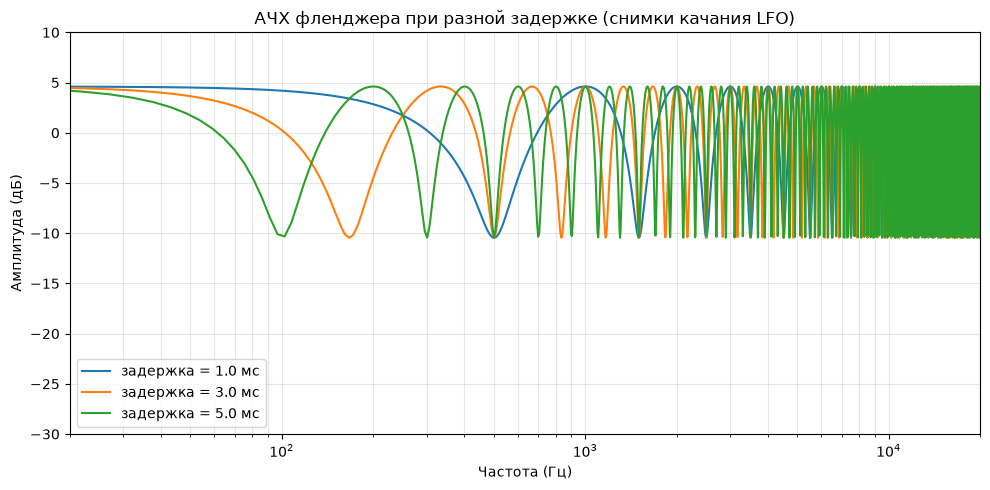

График сохранён в flanger_frequency_response.png
Готово.


In [2]:
"""
Фленджер (Flanger) — эффект на основе переменной задержки
и построение его частотной характеристики (АЧХ).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

SAMPLE_RATE = 44100


# ============================================================
# 1. САМ ЭФФЕКТ ФЛЕНДЖЕРА
# ============================================================

def flanger(signal, sample_rate=SAMPLE_RATE,
            rate_hz=1, depth_ms=3.0, base_delay_ms=3.0,
            mix=1, feedback=0.8):
    """
    Применяет эффект фленджера к сигналу.

    rate_hz     — скорость качания LFO (сколько раз в секунду "плывёт" задержка)
    depth_ms    — глубина модуляции задержки в миллисекундах
    base_delay_ms — базовая (средняя) задержка в миллисекундах
    mix         — доля обработанного сигнала в итоговом миксе (0..1)
    feedback    — доля сигнала, возвращаемая обратно на вход (усиливает резонансы)
    """
    n = len(signal)
    output = np.zeros(n)

    # LFO (Low Frequency Oscillator) — синусоида, управляющая задержкой во времени
    t = np.arange(n) / sample_rate
    lfo = np.sin(2 * np.pi * rate_hz * t)

    # Задержка в сэмплах, "плывущая" от (base-depth) до (base+depth)
    delay_samples = (base_delay_ms + depth_ms * lfo) * sample_rate / 1000.0

    # Буфер для feedback — храним уже обработанный сигнал
    delayed_signal = np.zeros(n)

    for i in range(n):
        d = delay_samples[i]
        idx = i - d  # дробный индекс в прошлое

        if idx < 0:
            sample = 0.0
        else:
            # Линейная интерполяция между двумя соседними сэмплами,
            # т.к. задержка дробная (не целое число сэмплов)
            idx_floor = int(np.floor(idx))
            frac = idx - idx_floor
            s0 = signal[idx_floor] + feedback * delayed_signal[idx_floor]
            if idx_floor + 1 < n:
                s1 = signal[idx_floor + 1] + feedback * delayed_signal[idx_floor + 1]
            else:
                s1 = s0
            sample = s0 * (1 - frac) + s1 * frac

        delayed_signal[i] = sample
        output[i] = (1 - mix) * signal[i] + mix * sample

    return output


# ============================================================
# 2. ЧАСТОТНАЯ ХАРАКТЕРИСТИКА (АЧХ)
# ============================================================
#
# Фленджер в каждый конкретный момент времени — это гребенчатый
# фильтр (comb filter) с фиксированной задержкой d:
#     y[n] = x[n] + g * x[n - d]
#
# Это FIR-фильтр с импульсной характеристикой:
#     h = [1, 0, 0, ..., 0, g]   (g стоит на позиции d)
#
# Мы построим АЧХ для нескольких "снимков" задержки —
# это как остановить качание LFO в разных точках и посмотреть,
# как выглядит гребёнка в каждый момент.

def comb_filter_response(delay_ms, gain, sample_rate=SAMPLE_RATE, n_points=4096):
    """Возвращает частоты и АЧХ (в дБ) гребенчатого фильтра с заданной задержкой."""
    delay_samples = int(round(delay_ms * sample_rate / 1000.0))

    h = np.zeros(delay_samples + 1)
    h[0] = 1.0
    h[delay_samples] = gain

    w, H = freqz(h, worN=n_points, fs=sample_rate)
    magnitude_db = 20 * np.log10(np.abs(H) + 1e-12)

    return w, magnitude_db


def plot_flanger_frequency_response():
    """Строит АЧХ гребенчатого фильтра для нескольких значений задержки."""
    gain = 0.7
    delays_ms = [1.0, 3.0, 5.0]  # три "снимка" качания LFO

    plt.figure(figsize=(10, 5))
    for d in delays_ms:
        freqs, mag_db = comb_filter_response(d, gain)
        plt.plot(freqs, mag_db, label=f"задержка = {d} мс")

    plt.xscale('log')
    plt.xlim(20, 20000)
    plt.ylim(-30, 10)
    plt.xlabel("Частота (Гц)")
    plt.ylabel("Амплитуда (дБ)")
    plt.title("АЧХ фленджера при разной задержке (снимки качания LFO)")
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.savefig("flanger_frequency_response.png", dpi=150)
    plt.show()
    print("График сохранён в flanger_frequency_response.png")


# ============================================================
# 3. ЗАПУСК
# ============================================================

if __name__ == "__main__":
    # Тестовый сигнал — белый шум (хорошо показывает гребёнку на слух и на графике)
    duration = 3.0
    test_signal = np.random.uniform(-0.3, 0.3, int(SAMPLE_RATE * duration))

    print("Применяем фленджер к тестовому сигналу...")
    processed = flanger(test_signal)

    print("Строим частотную характеристику...")
    plot_flanger_frequency_response()

    print("Готово.")